## Boston Bautista

Question: Which industries show the most consistent profitability and which experience the highest volatility?

In [1]:
import os
import pyspark
from math import sqrt

sc = pyspark.SparkContext().getOrCreate()

25/12/02 10:57:55 WARN Utils: Your hostname, MacBook-Pro-246.local resolves to a loopback address: 127.0.0.1; using 10.0.0.137 instead (on interface en0)
25/12/02 10:57:55 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/02 10:57:56 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
import argparse

parser = argparse.ArgumentParser()
parser.add_argument(
    "--is-local",
    type=str,
    default="true",
    help="Whether running in local mode",
)

args, unknown = parser.parse_known_args()
is_local = args.is_local.lower() == "true"
if is_local:
    prefix = "../data/processed/merged"
else:
    prefix = "gs://msds-694-cohort-14-3/data"

print(f"Is local environment: {is_local}")

num_csv_path = f"{prefix}/num_2020.csv"
pre_csv_path = f"{prefix}/pre_2020.csv"
sub_csv_path = f"{prefix}/sub_2020.csv"
tag_csv_path = f"{prefix}/tag_2020.csv"

print(f"Num CSV path: {num_csv_path}")
print(f"Pre CSV path: {pre_csv_path}")
print(f"Sub CSV path: {sub_csv_path}")
print(f"Tag CSV path: {tag_csv_path}")

num_rdd = sc.textFile(num_csv_path)
pre_rdd = sc.textFile(pre_csv_path)
sub_rdd = sc.textFile(sub_csv_path)
tag_rdd = sc.textFile(tag_csv_path)

# print size of each RDD
print(f"Num RDD size: {num_rdd.count()}")
print(f"Pre RDD size: {pre_rdd.count()}")
print(f"Sub RDD size: {sub_rdd.count()}")
print(f"Tag RDD size: {tag_rdd.count()}")

Is local environment: True
Num CSV path: ../data/processed/merged/num_2020.csv
Pre CSV path: ../data/processed/merged/pre_2020.csv
Sub CSV path: ../data/processed/merged/sub_2020.csv
Tag CSV path: ../data/processed/merged/tag_2020.csv


Num RDD size: 11493263


Pre RDD size: 2746310
Sub RDD size: 24940
Tag RDD size: 298803


In [3]:
num_header_line = num_rdd.first()
sub_header_line = sub_rdd.first()

num_header = num_header_line.split(",")
sub_header = sub_header_line.split(",")

num_body = (num_rdd.filter(lambda x: x != num_header_line)\
            .map(lambda x: x.split(","))\
            .filter(lambda x: len(x) == len(num_header)))

sub_body = (sub_rdd.filter(lambda x: x != sub_header_line)\
            .map(lambda x: x.split(","))\
            .filter(lambda x: len(x) == len(sub_header)))

In [4]:
n_adsh  = num_header.index("adsh")
n_tag   = num_header.index("tag")
n_uom   = num_header.index("uom")
n_seg   = num_header.index("segments")
n_coreg = num_header.index("coreg")
n_val   = num_header.index("value")
s_adsh  = sub_header.index("adsh")
s_sic   = sub_header.index("sic")

In [5]:
cat = {"NetIncomeLoss", "Assets"}

num_filtered = num_body.filter(lambda x: (
    x[n_tag] in cat and x[n_uom] == "USD" and\
    x[n_seg] == "" and x[n_coreg] == "" and\
    x[n_val] != ""))

In [6]:
num_tag_val = num_filtered.map(lambda x: (x[n_adsh], x[n_tag], float(x[n_val])))

ni_rdd = (num_tag_val.filter(lambda x: x[1] == "NetIncomeLoss")\
    .map(lambda x: (x[0], x[2])))

assets_rdd = (num_tag_val.filter(lambda x: x[1] == "Assets")\
    .map(lambda x: (x[0], x[2])))

In [7]:
filings = ni_rdd.join(assets_rdd)

filings_pos = filings.filter(lambda x: x[1][1] > 0)

sub_pairs = (sub_body.filter(lambda x: x[s_sic] != "")\
    .map(lambda x: (x[s_adsh], str(int(float(x[s_sic]))))))

In [8]:
filings_with_sic = filings_pos.join(sub_pairs)

roa_by_sic = filings_with_sic.map(\
    lambda x: (x[1][1], x[1][0][0] / x[1][0][1]))

In [9]:
sic_stats_raw = (roa_by_sic\
    .map(lambda x: (x[0], (x[1], x[1] * x[1], 1)))\
    .reduceByKey(lambda x, y: (x[0] + y[0], x[1] + y[1], x[2] + y[2])))

In [10]:
sic_stats = sic_stats_raw.map(lambda x: (
    x[0], x[1][0] / x[1][2],
    sqrt(max((x[1][1] / x[1][2]) - (x[1][0] / x[1][2])**2, 0)),
    x[1][2]))

In [11]:
sic_lookup_path = "/Users/bostonbautista/Desktop/MSDS_694/Distributed_computing_group_project/data/SIC_Lookup.csv"

sic_lookup_rdd = (
    sc.textFile(sic_lookup_path)\
    .map(lambda x: x.split(","))\
    .filter(lambda x: len(x) >= 2 and x[0] != "sic")\
    .map(lambda x: (x[0], x[1])))

sic_named = (sic_stats
    .map(lambda x: (x[0], (x[1], x[2], x[3])))\
    .join(sic_lookup_rdd)\
    .map(lambda x: (x[0], x[1][0][0], x[1][0][1], x[1][0][2], x[1][1])))

In [12]:
top_avg = sic_named.sortBy(lambda x: x[1], ascending=False).take(5)
top_vol = sic_named.sortBy(lambda x: x[2], ascending=False).take(5)

import pandas as pd
import matplotlib.pyplot as plt

cols = ["sic", "avg_roa", "std_roa", "n", "industry"]

df_avg = pd.DataFrame(top_avg, columns=cols).sort_values("avg_roa")
df_vol = pd.DataFrame(top_vol, columns=cols).sort_values("std_roa")

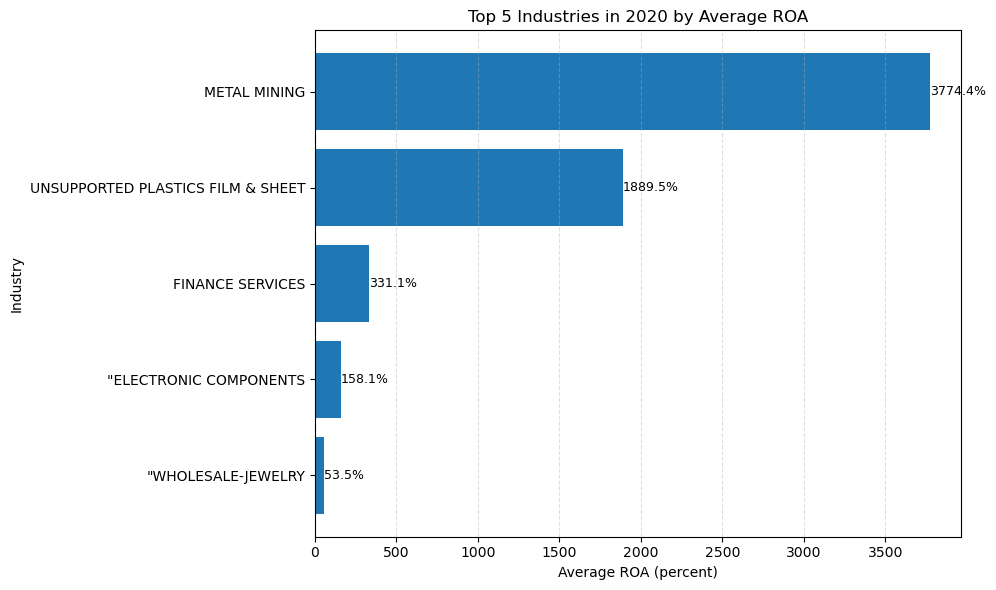

In [13]:
plt.figure(figsize=(10, 6))
avg_pct = df_avg["avg_roa"] * 100
plt.barh(df_avg["industry"], avg_pct)
plt.xlabel("Average ROA (percent)")
plt.ylabel("Industry")
plt.title("Top 5 Industries in 2020 by Average ROA")
plt.grid(axis="x", linestyle="--", alpha=0.4)

for y, v in enumerate(avg_pct):
    plt.text(v + 0.1, y, f"{v:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

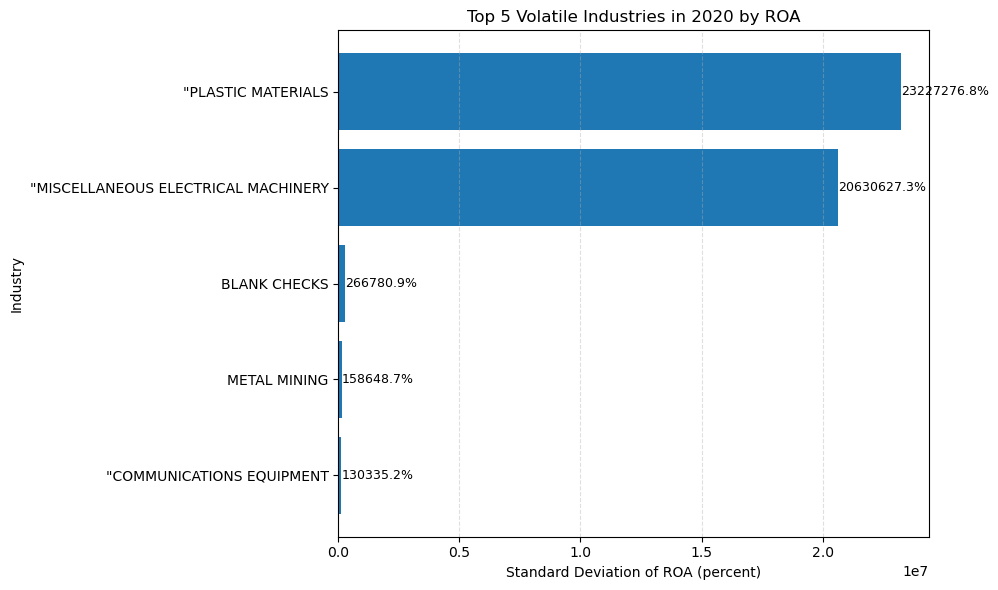

In [14]:
plt.figure(figsize=(10, 6))
std_pct = df_vol["std_roa"] * 100
plt.barh(df_vol["industry"], std_pct)
plt.xlabel("Standard Deviation of ROA (percent)")
plt.ylabel("Industry")
plt.title("Top 5 Volatile Industries in 2020 by ROA")
plt.grid(axis="x", linestyle="--", alpha=0.4)

for y, v in enumerate(std_pct):
    plt.text(v + 0.1, y, f"{v:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

In [15]:
sc.stop()